送信側
送信文字列:
LFSR SYNC TEST

送信データビット:
0100110001000110010100110101001000100000010100110101100101001110010000110010000001010100010001010101001101010100

送信データビット数: 112

送信データビットの内訳
総ビット数: 112
ASCII文字数: 14

  番号         ビット位置         8ビット    16進    10進       文字
----------------------------------------------------------------------------------
   1     0-7         01001100     4C     76        L
   2     8-15        01000110     46     70        F
   3    16-23        01010011     53     83        S
   4    24-31        01010010     52     82        R
   5    32-39        00100000     20     32       空白
   6    40-47        01010011     53     83        S
   7    48-55        01011001     59     89        Y
   8    56-63        01001110     4E     78        N
   9    64-71        01000011     43     67        C
  10    72-79        00100000     20     32       空白
  11    80-87        01010100     54     84        T
  12    88-95        01000101     45     69        E
  13    96-103       0

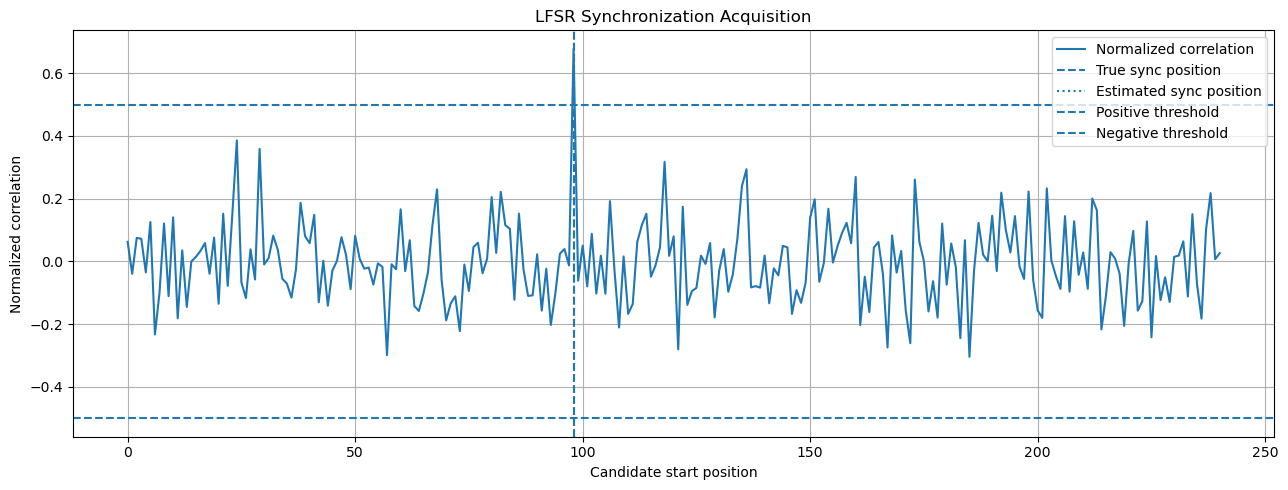

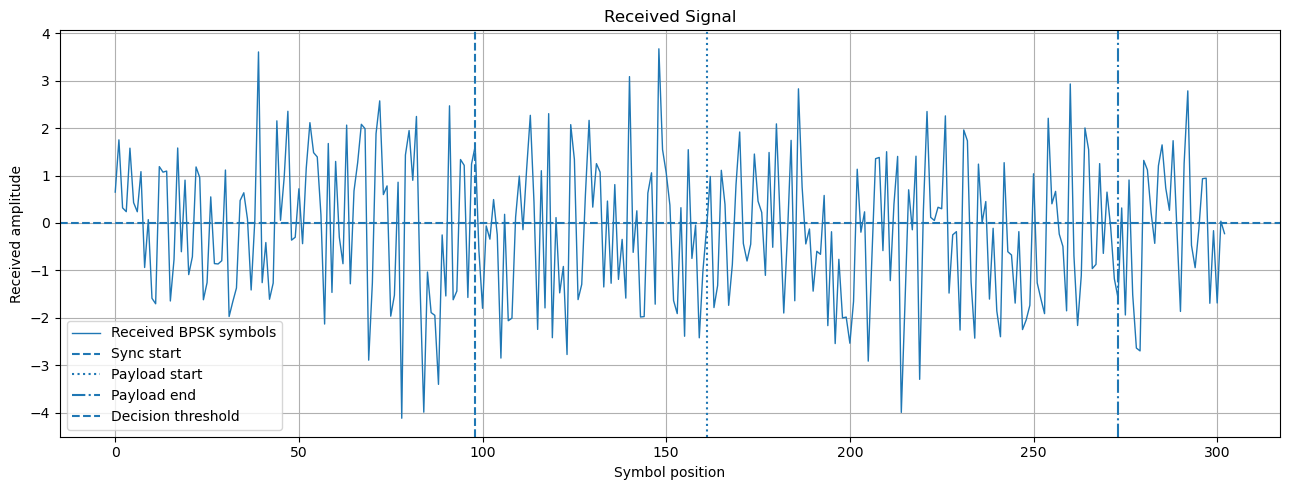

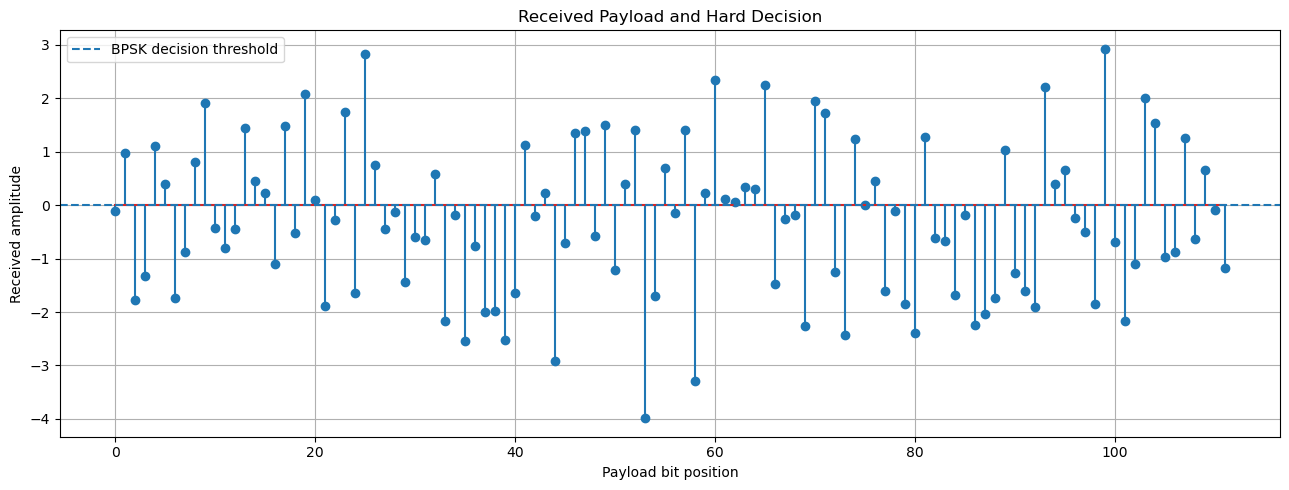

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LFSR系列の生成
# ============================================================

def generate_lfsr_sequence(initial_state, taps, length):
    """
    LFSRから0/1のPN系列を生成する。

    Parameters
    ----------
    initial_state : list[int]
        LFSRの初期状態。全ビット0は禁止。

    taps : list[int]
        XORを計算するレジスタ位置。
        左端を0番とする。

    length : int
        生成するビット数。

    Returns
    -------
    np.ndarray
        0/1のLFSR系列。
    """

    state = list(initial_state)

    if not state:
        raise ValueError("初期状態を指定してください。")

    if any(bit not in (0, 1) for bit in state):
        raise ValueError("初期状態には0または1を指定してください。")

    if all(bit == 0 for bit in state):
        raise ValueError("LFSRの初期状態をすべて0にはできません。")

    if any(tap < 0 or tap >= len(state) for tap in taps):
        raise ValueError("タップ位置がレジスタ範囲外です。")

    if length <= 0:
        raise ValueError("系列長は1以上にしてください。")

    sequence = []

    for _ in range(length):

        # 右端ビットを出力
        output_bit = state[-1]
        sequence.append(output_bit)

        # タップ位置のXOR
        feedback = 0

        for tap in taps:
            feedback ^= state[tap]

        # 右方向へシフト
        state = [feedback] + state[:-1]

    return np.array(sequence, dtype=np.int8)


# ============================================================
# 2. 文字列とビット列の変換
# ============================================================

def text_to_bits(text):
    """
    ASCII文字列を8ビット単位のビット列へ変換する。
    """

    try:
        encoded = text.encode("ascii")
    except UnicodeEncodeError as error:
        raise ValueError(
            "このサンプルではASCII文字だけを使用してください。"
        ) from error

    bits = []

    for byte in encoded:

        for bit_position in range(7, -1, -1):

            bit = (byte >> bit_position) & 1
            bits.append(bit)

    return np.array(bits, dtype=np.int8)


def bits_to_text(bits):
    """
    0/1ビット列を8ビットずつASCII文字へ復号する。

    表示できないASCIIコードは「?」に置き換える。
    """

    bits = np.asarray(bits, dtype=np.int8)

    usable_length = len(bits) - len(bits) % 8
    bits = bits[:usable_length]

    decoded_characters = []

    for start in range(0, usable_length, 8):

        byte_bits = bits[start:start + 8]

        value = 0

        for bit in byte_bits:
            value = (value << 1) | int(bit)

        if 32 <= value <= 126:
            decoded_characters.append(chr(value))
        else:
            decoded_characters.append("?")

    return "".join(decoded_characters)


# ============================================================
# 3. BPSK変調・復調
# ============================================================

def bits_to_bpsk(bits):
    """
    0 -> -1
    1 -> +1
    """

    bits = np.asarray(bits, dtype=float)

    return 2.0 * bits - 1.0


def bpsk_to_bits(symbols):
    """
    受信振幅を硬判定する。

    0以上 -> 1
    0未満 -> 0
    """

    symbols = np.asarray(symbols, dtype=float)

    return (symbols >= 0).astype(np.int8)


# ============================================================
# 4. ビット列を整形して表示
# ============================================================

def bit_array_to_string(bits):
    """
    0/1配列を連続した文字列へ変換する。
    """

    return "".join(str(int(bit)) for bit in bits)


def print_bits_with_positions(
    bits,
    bits_per_line=80,
    start_position=0
):
    """
    ビット列を位置番号付きで表示する。
    """

    bits = np.asarray(bits, dtype=np.int8)
    bit_string = bit_array_to_string(bits)

    if len(bit_string) == 0:
        print("(なし)")
        return

    for local_start in range(
        0,
        len(bit_string),
        bits_per_line
    ):
        local_end = min(
            local_start + bits_per_line,
            len(bit_string)
        )

        global_start = start_position + local_start
        global_end = start_position + local_end - 1

        print(
            f"{global_start:4d}-{global_end:4d}: "
            f"{bit_string[local_start:local_end]}"
        )


# ============================================================
# 5. ペイロード112ビットの内訳表示
# ============================================================

def print_payload_breakdown(payload_bits):
    """
    ペイロードを8ビット単位に分解して、
    ASCII文字との対応を表示する。
    """

    payload_bits = np.asarray(
        payload_bits,
        dtype=np.int8
    )

    usable_length = (
        len(payload_bits)
        - len(payload_bits) % 8
    )

    print()
    print("=" * 82)
    print("送信データビットの内訳")
    print("=" * 82)

    print("総ビット数:", len(payload_bits))
    print("ASCII文字数:", usable_length // 8)

    print()
    print(
        f"{'番号':>4} "
        f"{'ビット位置':>13} "
        f"{'8ビット':>12} "
        f"{'16進':>6} "
        f"{'10進':>6} "
        f"{'文字':>8}"
    )

    print("-" * 82)

    decoded_characters = []

    for character_number, start in enumerate(
        range(0, usable_length, 8),
        start=1
    ):

        byte_bits = payload_bits[start:start + 8]

        bit_string = bit_array_to_string(
            byte_bits
        )

        decimal_value = int(bit_string, 2)
        hexadecimal_value = f"{decimal_value:02X}"

        if decimal_value == 32:
            display_character = "空白"
            decoded_characters.append(" ")

        elif 32 <= decimal_value <= 126:
            display_character = chr(decimal_value)
            decoded_characters.append(
                display_character
            )

        else:
            display_character = "制御"
            decoded_characters.append("?")

        end = start + 7

        print(
            f"{character_number:4d} "
            f"{start:5d}-{end:<5d} "
            f"{bit_string:>12} "
            f"{hexadecimal_value:>6} "
            f"{decimal_value:6d} "
            f"{display_character:>8}"
        )

    print("-" * 82)

    grouped_bits = []

    for start in range(0, usable_length, 8):

        grouped_bits.append(
            bit_array_to_string(
                payload_bits[start:start + 8]
            )
        )

    print()
    print("8ビット区切り:")
    print(" ".join(grouped_bits))

    print()
    print("復元文字列:")
    print("".join(decoded_characters))

    print()
    print(
        f"{usable_length // 8}文字 × 8ビット "
        f"= {usable_length}ビット"
    )


# ============================================================
# 6. 送信側
# ============================================================

def transmitter(
    message="LFSR SYNC TEST",
    sync_length=63,
    prefix_length=None,
    suffix_length=30,
    seed=1234
):
    """
    同期系列、ASCIIデータ、前後のランダム系列を作成する。

    全送信系列:
        先行ランダム
        + LFSR同期系列
        + ASCIIペイロード
        + 後続ランダム
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # 6段LFSRによる同期系列
    # 最大周期は 2^6 - 1 = 63
    # --------------------------------------------------------

    sync_bits = generate_lfsr_sequence(
        initial_state=[1, 0, 0, 0, 0, 1],
        taps=[0, 5],
        length=sync_length
    )

    # --------------------------------------------------------
    # 文字列をASCIIビットへ変換
    # --------------------------------------------------------

    payload_bits = text_to_bits(message)

    # --------------------------------------------------------
    # 同期開始位置を分からなくするための先行系列
    # --------------------------------------------------------

    if prefix_length is None:
        prefix_length = int(
            rng.integers(30, 100)
        )

    prefix_bits = rng.integers(
        low=0,
        high=2,
        size=prefix_length,
        dtype=np.int8
    )

    # --------------------------------------------------------
    # 後続ランダム系列
    # --------------------------------------------------------

    suffix_bits = rng.integers(
        low=0,
        high=2,
        size=suffix_length,
        dtype=np.int8
    )

    # --------------------------------------------------------
    # 同期系列＋データ
    # --------------------------------------------------------

    frame_bits = np.concatenate([
        sync_bits,
        payload_bits
    ])

    # --------------------------------------------------------
    # 実際に送信する全ビット系列
    # --------------------------------------------------------

    transmitted_bits = np.concatenate([
        prefix_bits,
        frame_bits,
        suffix_bits
    ])

    # BPSK変調
    transmitted_symbols = bits_to_bpsk(
        transmitted_bits
    )

    sync_start = prefix_length
    sync_end = sync_start + len(sync_bits)

    payload_start = sync_end
    payload_end = payload_start + len(payload_bits)

    return {
        "message": message,
        "prefix_bits": prefix_bits,
        "sync_bits": sync_bits,
        "payload_bits": payload_bits,
        "suffix_bits": suffix_bits,
        "frame_bits": frame_bits,
        "transmitted_bits": transmitted_bits,
        "transmitted_symbols": transmitted_symbols,
        "true_sync_start": sync_start,
        "sync_end": sync_end,
        "payload_start": payload_start,
        "payload_end": payload_end
    }


# ============================================================
# 7. 実際の送信シーケンスを表示
# ============================================================

def print_transmitted_sequence(
    tx,
    bits_per_line=80
):
    """
    実際に送信する全系列を領域ごとに表示する。
    """

    prefix_bits = tx["prefix_bits"]
    sync_bits = tx["sync_bits"]
    payload_bits = tx["payload_bits"]
    suffix_bits = tx["suffix_bits"]

    transmitted_bits = tx["transmitted_bits"]
    transmitted_symbols = tx[
        "transmitted_symbols"
    ]

    prefix_length = len(prefix_bits)
    sync_length = len(sync_bits)
    payload_length = len(payload_bits)
    suffix_length = len(suffix_bits)

    total_length = len(transmitted_bits)

    sync_start = tx["true_sync_start"]
    sync_end = tx["sync_end"]

    payload_start = tx["payload_start"]
    payload_end = tx["payload_end"]

    print()
    print("=" * 82)
    print("実際に送信している全シーケンス")
    print("=" * 82)

    print(
        "先行ランダムビット数:",
        prefix_length
    )
    print(
        "同期系列ビット数:",
        sync_length
    )
    print(
        "送信データビット数:",
        payload_length
    )
    print(
        "後続ランダムビット数:",
        suffix_length
    )
    print(
        "フレーム本体のビット数:",
        sync_length + payload_length
    )
    print(
        "全送信シーケンスのビット数:",
        total_length
    )

    print()
    print(
        "構成:",
        f"{prefix_length} + "
        f"{sync_length} + "
        f"{payload_length} + "
        f"{suffix_length} = "
        f"{total_length}ビット"
    )

    print()
    print("[先行ランダムビット]")
    print_bits_with_positions(
        prefix_bits,
        bits_per_line=bits_per_line,
        start_position=0
    )

    print()
    print("[LFSR同期系列]")
    print_bits_with_positions(
        sync_bits,
        bits_per_line=bits_per_line,
        start_position=sync_start
    )

    print()
    print("[ASCII送信データ]")
    print_bits_with_positions(
        payload_bits,
        bits_per_line=bits_per_line,
        start_position=payload_start
    )

    print()
    print("[後続ランダムビット]")
    print_bits_with_positions(
        suffix_bits,
        bits_per_line=bits_per_line,
        start_position=payload_end
    )

    print()
    print("[実際の全送信ビット列]")
    print_bits_with_positions(
        transmitted_bits,
        bits_per_line=bits_per_line,
        start_position=0
    )

    print()
    print("[各領域の位置]")

    if prefix_length > 0:
        print(
            f"先行ランダム: 0-"
            f"{sync_start - 1}"
        )
    else:
        print("先行ランダム: なし")

    print(
        f"同期系列:     "
        f"{sync_start}-{sync_end - 1}"
    )

    print(
        f"送信データ:   "
        f"{payload_start}-{payload_end - 1}"
    )

    if suffix_length > 0:
        print(
            f"後続ランダム: "
            f"{payload_end}-{total_length - 1}"
        )
    else:
        print("後続ランダム: なし")

    print()
    print("[BPSK変調規則]")
    print("0 -> -1")
    print("1 -> +1")

    print()
    print("[BPSK変調後の送信シンボル]")

    symbols_per_line = 20

    for start in range(
        0,
        len(transmitted_symbols),
        symbols_per_line
    ):

        end = min(
            start + symbols_per_line,
            len(transmitted_symbols)
        )

        symbol_text = " ".join(
            f"{symbol:+.0f}"
            for symbol
            in transmitted_symbols[start:end]
        )

        print(
            f"{start:4d}-{end - 1:4d}: "
            f"{symbol_text}"
        )


# ============================================================
# 8. AWGN通信路
# ============================================================

def channel(
    transmitted_symbols,
    snr_db=0.0,
    polarity_inversion=False,
    seed=5678
):
    """
    BPSK信号へガウス雑音を追加する。

    Parameters
    ----------
    transmitted_symbols : np.ndarray
        BPSK変調済み信号。

    snr_db : float
        信号対雑音比[dB]。

    polarity_inversion : bool
        Trueの場合、信号全体の符号を反転する。

    seed : int
        乱数シード。
    """

    rng = np.random.default_rng(seed)

    signal = np.asarray(
        transmitted_symbols,
        dtype=float
    ).copy()

    if polarity_inversion:
        signal *= -1.0

    signal_power = np.mean(signal ** 2)

    snr_linear = 10.0 ** (snr_db / 10.0)

    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)

    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=len(signal)
    )

    received_symbols = signal + noise

    return {
        "received_symbols": received_symbols,
        "noise": noise,
        "noise_std": noise_std,
        "signal_power": signal_power,
        "noise_power": noise_power
    }


# ============================================================
# 9. 正規化相関
# ============================================================

def normalized_correlation(
    received,
    reference
):
    """
    各候補位置で受信信号と同期系列の正規化相関を計算する。
    """

    received = np.asarray(
        received,
        dtype=float
    )

    reference = np.asarray(
        reference,
        dtype=float
    )

    reference_length = len(reference)

    if len(received) < reference_length:
        raise ValueError(
            "受信信号が同期系列より短いため、"
            "同期捕捉できません。"
        )

    correlation_length = (
        len(received)
        - reference_length
        + 1
    )

    correlations = np.zeros(
        correlation_length,
        dtype=float
    )

    reference_energy = np.sum(
        reference ** 2
    )

    for start in range(correlation_length):

        segment = received[
            start:start + reference_length
        ]

        segment_energy = np.sum(
            segment ** 2
        )

        denominator = np.sqrt(
            reference_energy
            * segment_energy
        )

        if denominator > 0:

            correlations[start] = (
                np.sum(segment * reference)
                / denominator
            )

    return correlations


# ============================================================
# 10. 受信側
# ============================================================

def receiver(
    received_symbols,
    sync_bits,
    payload_length,
    threshold=0.5,
    allow_polarity_inversion=True
):
    """
    相関により同期位置を推定し、
    ペイロードをBPSK復調して文字列へ復号する。
    """

    sync_symbols = bits_to_bpsk(
        sync_bits
    )

    correlations = normalized_correlation(
        received_symbols,
        sync_symbols
    )

    if allow_polarity_inversion:

        estimated_sync_start = int(
            np.argmax(np.abs(correlations))
        )

        peak_correlation = correlations[
            estimated_sync_start
        ]

        detection_value = abs(
            peak_correlation
        )

    else:

        estimated_sync_start = int(
            np.argmax(correlations)
        )

        peak_correlation = correlations[
            estimated_sync_start
        ]

        detection_value = peak_correlation

    synchronized = (
        detection_value >= threshold
    )

    if not synchronized:

        return {
            "synchronized": False,
            "estimated_sync_start": None,
            "peak_correlation": peak_correlation,
            "correlations": correlations,
            "payload_start": None,
            "payload_end": None,
            "polarity_inverted": None,
            "received_payload_symbols": None,
            "received_payload_bits": None,
            "decoded_text": None
        }

    polarity_inverted = (
        peak_correlation < 0
    )

    payload_start = (
        estimated_sync_start
        + len(sync_bits)
    )

    payload_end = (
        payload_start
        + payload_length
    )

    if payload_end > len(received_symbols):
        raise ValueError(
            "同期位置以降の受信データが不足しています。"
        )

    received_payload_symbols = (
        received_symbols[
            payload_start:payload_end
        ].copy()
    )

    # 負の相関ピークなら極性を補正
    if polarity_inverted:
        received_payload_symbols *= -1.0

    received_payload_bits = bpsk_to_bits(
        received_payload_symbols
    )

    decoded_text = bits_to_text(
        received_payload_bits
    )

    return {
        "synchronized": True,
        "estimated_sync_start": estimated_sync_start,
        "peak_correlation": peak_correlation,
        "correlations": correlations,
        "payload_start": payload_start,
        "payload_end": payload_end,
        "polarity_inverted": polarity_inverted,
        "received_payload_symbols": received_payload_symbols,
        "received_payload_bits": received_payload_bits,
        "decoded_text": decoded_text
    }


# ============================================================
# 11. 復号結果の評価
# ============================================================

def evaluate_decoding(
    transmitted_bits,
    received_bits
):
    """
    送信ビットと受信ビットを比較する。
    """

    transmitted_bits = np.asarray(
        transmitted_bits,
        dtype=np.int8
    )

    received_bits = np.asarray(
        received_bits,
        dtype=np.int8
    )

    if len(transmitted_bits) != len(received_bits):
        raise ValueError(
            "送信ビット数と受信ビット数が異なります。"
        )

    error_mask = (
        transmitted_bits != received_bits
    )

    error_positions = np.where(
        error_mask
    )[0]

    error_count = len(error_positions)

    total_bits = len(transmitted_bits)

    ber = (
        error_count / total_bits
        if total_bits > 0
        else 0.0
    )

    correct_rate = 1.0 - ber

    return {
        "error_mask": error_mask,
        "error_positions": error_positions,
        "error_count": error_count,
        "total_bits": total_bits,
        "ber": ber,
        "correct_rate": correct_rate
    }


def print_bit_comparison(
    transmitted_bits,
    received_bits,
    bits_per_line=64
):
    """
    送信ビットと復号ビットを比較表示する。

    . : 一致
    X : 不一致
    """

    transmitted_bits = np.asarray(
        transmitted_bits,
        dtype=np.int8
    )

    received_bits = np.asarray(
        received_bits,
        dtype=np.int8
    )

    print()
    print("記号の意味:")
    print(". : 送信ビットと復号ビットが一致")
    print("X : 送信ビットと復号ビットが不一致")
    print("    誤り訂正済みという意味ではありません。")

    print()

    for start in range(
        0,
        len(transmitted_bits),
        bits_per_line
    ):

        end = min(
            start + bits_per_line,
            len(transmitted_bits)
        )

        tx_part = transmitted_bits[
            start:end
        ]

        rx_part = received_bits[
            start:end
        ]

        tx_string = bit_array_to_string(
            tx_part
        )

        rx_string = bit_array_to_string(
            rx_part
        )

        comparison_string = "".join(
            "."
            if tx_bit == rx_bit
            else "X"
            for tx_bit, rx_bit
            in zip(tx_part, rx_part)
        )

        print(
            f"ビット位置 {start:4d}-{end - 1:4d}"
        )
        print("送信:", tx_string)
        print("復号:", rx_string)
        print("比較:", comparison_string)
        print()


# ============================================================
# 12. プロット
# ============================================================

def plot_results(
    tx,
    channel_result,
    rx,
    threshold
):
    """
    相関波形、受信信号、ペイロード判定結果を表示する。
    """

    received_symbols = channel_result[
        "received_symbols"
    ]

    # --------------------------------------------------------
    # 相関波形
    # --------------------------------------------------------

    plt.figure(figsize=(13, 5))

    plt.plot(
        rx["correlations"],
        label="Normalized correlation"
    )

    plt.axvline(
        tx["true_sync_start"],
        linestyle="--",
        label="True sync position"
    )

    if rx["synchronized"]:

        plt.axvline(
            rx["estimated_sync_start"],
            linestyle=":",
            label="Estimated sync position"
        )

    plt.axhline(
        threshold,
        linestyle="--",
        label="Positive threshold"
    )

    plt.axhline(
        -threshold,
        linestyle="--",
        label="Negative threshold"
    )

    plt.xlabel("Candidate start position")
    plt.ylabel("Normalized correlation")
    plt.title(
        "LFSR Synchronization Acquisition"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 受信信号全体
    # --------------------------------------------------------

    plt.figure(figsize=(13, 5))

    plt.plot(
        received_symbols,
        linewidth=1,
        label="Received BPSK symbols"
    )

    plt.axvline(
        tx["true_sync_start"],
        linestyle="--",
        label="Sync start"
    )

    plt.axvline(
        tx["sync_end"],
        linestyle=":",
        label="Payload start"
    )

    plt.axvline(
        tx["payload_end"],
        linestyle="-.",
        label="Payload end"
    )

    plt.axhline(
        0,
        linestyle="--",
        label="Decision threshold"
    )

    plt.xlabel("Symbol position")
    plt.ylabel("Received amplitude")
    plt.title("Received Signal")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 受信ペイロード
    # --------------------------------------------------------

    if rx["synchronized"]:

        payload_symbols = rx[
            "received_payload_symbols"
        ]

        plt.figure(figsize=(13, 5))

        markerline, stemlines, baseline = plt.stem(
            np.arange(len(payload_symbols)),
            payload_symbols
        )

        plt.axhline(
            0,
            linestyle="--",
            label="BPSK decision threshold"
        )

        plt.xlabel("Payload bit position")
        plt.ylabel("Received amplitude")
        plt.title(
            "Received Payload and Hard Decision"
        )

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


# ============================================================
# 13. メイン処理
# ============================================================

def main():

    # --------------------------------------------------------
    # 設定
    # --------------------------------------------------------

    transmitted_message = "LFSR SYNC TEST"

    # 6段LFSRの最大周期
    sync_length = 63

    # Noneなら30～99ビットからランダムに決定
    prefix_length = None

    suffix_length = 30

    # 小さいほど雑音が強い
    snr_db = -1.0

    # 同期判定しきい値
    correlation_threshold = 0.5

    # 通信路で極性反転を発生させるか
    polarity_inversion = False

    # --------------------------------------------------------
    # 送信側
    # --------------------------------------------------------

    tx = transmitter(
        message=transmitted_message,
        sync_length=sync_length,
        prefix_length=prefix_length,
        suffix_length=suffix_length,
        seed=1234
    )

    print("=" * 82)
    print("送信側")
    print("=" * 82)

    print("送信文字列:")
    print(tx["message"])

    print()
    print("送信データビット:")
    print(
        bit_array_to_string(
            tx["payload_bits"]
        )
    )

    print()
    print(
        "送信データビット数:",
        len(tx["payload_bits"])
    )

    # ASCIIデータの112ビット内訳
    print_payload_breakdown(
        tx["payload_bits"]
    )

    # 実際の全送信シーケンス
    print_transmitted_sequence(
        tx,
        bits_per_line=80
    )

    # --------------------------------------------------------
    # 通信路
    # --------------------------------------------------------

    channel_result = channel(
        transmitted_symbols=tx[
            "transmitted_symbols"
        ],
        snr_db=snr_db,
        polarity_inversion=polarity_inversion,
        seed=5678
    )

    received_symbols = channel_result[
        "received_symbols"
    ]

    print()
    print("=" * 82)
    print("通信路")
    print("=" * 82)

    print(f"SNR: {snr_db:.2f} dB")

    print(
        f"雑音標準偏差: "
        f"{channel_result['noise_std']:.6f}"
    )

    print(
        "通信路での極性反転:",
        polarity_inversion
    )

    # --------------------------------------------------------
    # 受信側
    # --------------------------------------------------------

    rx = receiver(
        received_symbols=received_symbols,
        sync_bits=tx["sync_bits"],
        payload_length=len(
            tx["payload_bits"]
        ),
        threshold=correlation_threshold,
        allow_polarity_inversion=True
    )

    print()
    print("=" * 82)
    print("同期捕捉結果")
    print("=" * 82)

    print(
        f"最大相関値: "
        f"{rx['peak_correlation']:.6f}"
    )

    print(
        "実際の同期開始位置:",
        tx["true_sync_start"]
    )

    if not rx["synchronized"]:

        print("同期捕捉に失敗しました。")

        plot_results(
            tx=tx,
            channel_result=channel_result,
            rx=rx,
            threshold=correlation_threshold
        )

        return

    print("同期捕捉に成功しました。")

    print(
        "推定同期開始位置:",
        rx["estimated_sync_start"]
    )

    print(
        "同期位置の誤差:",
        rx["estimated_sync_start"]
        - tx["true_sync_start"]
    )

    print(
        "推定ペイロード開始位置:",
        rx["payload_start"]
    )

    print(
        "実際のペイロード開始位置:",
        tx["payload_start"]
    )

    print(
        "極性反転の検出:",
        rx["polarity_inverted"]
    )

    # --------------------------------------------------------
    # 復号結果
    # --------------------------------------------------------

    evaluation = evaluate_decoding(
        transmitted_bits=tx[
            "payload_bits"
        ],
        received_bits=rx[
            "received_payload_bits"
        ]
    )

    print()
    print("=" * 82)
    print("復号結果")
    print("=" * 82)

    print("送信文字列:")
    print(tx["message"])

    print()
    print("復号文字列:")
    print(rx["decoded_text"])

    print()
    print("送信データビット:")
    print(
        bit_array_to_string(
            tx["payload_bits"]
        )
    )

    print()
    print("復号データビット:")
    print(
        bit_array_to_string(
            rx["received_payload_bits"]
        )
    )

    print()
    print(
        "総データビット数:",
        evaluation["total_bits"]
    )

    print(
        "誤りビット数:",
        evaluation["error_count"]
    )

    print(
        f"BER: "
        f"{evaluation['ber']:.6f}"
    )

    print(
        f"ビット一致率: "
        f"{evaluation['correct_rate'] * 100:.2f}%"
    )

    print(
        "誤り位置:",
        evaluation[
            "error_positions"
        ].tolist()
    )

    # --------------------------------------------------------
    # ビット単位の比較
    # --------------------------------------------------------

    print()
    print("=" * 82)
    print("送信ビットと復号ビットの比較")
    print("=" * 82)

    print_bit_comparison(
        transmitted_bits=tx[
            "payload_bits"
        ],
        received_bits=rx[
            "received_payload_bits"
        ],
        bits_per_line=64
    )

    # --------------------------------------------------------
    # グラフ表示
    # --------------------------------------------------------

    plot_results(
        tx=tx,
        channel_result=channel_result,
        rx=rx,
        threshold=correlation_threshold
    )


# ============================================================
# 14. 実行
# ============================================================

if __name__ == "__main__":
    main()